Series data (cleaned):
  Series Resistance in kilo ohms  Voltage   Current  R_kOhm    R_Ohm       V  \
0    NaN                     0.2  47.2 mV  0.234 mA     0.2    200.0  0.0472   
1    NaN                       1  0.235 V  0.234 mA     1.0   1000.0  0.2350   
2    NaN                      20   4.72 V       NaN    20.0  20000.0  4.7200   

          I  
0  0.000234  
1  0.000234  
2       NaN  

Parallel data (cleaned):
  Series Resistance in kilo ohms Voltage   Current  R_kOhm    R_Ohm     V  \
0    NaN                     0.2  4.95 V   22.5 mA     0.2    200.0  4.95   
1    NaN                       1     NaN   5.74 mA     1.0   1000.0   NaN   
2    NaN                      20  4.87 V  0.244 mA    20.0  20000.0  4.87   

          I  
0  0.022500  
1  0.005740  
2  0.000244  

Series data with uncertainties:
     R_Ohm       V        uV         I        uI     uR
0    200.0  0.0472  0.000536  0.000234  0.000032    2.1
1   1000.0  0.2350  0.004175  0.000234  0.000032   11.0
2  20000

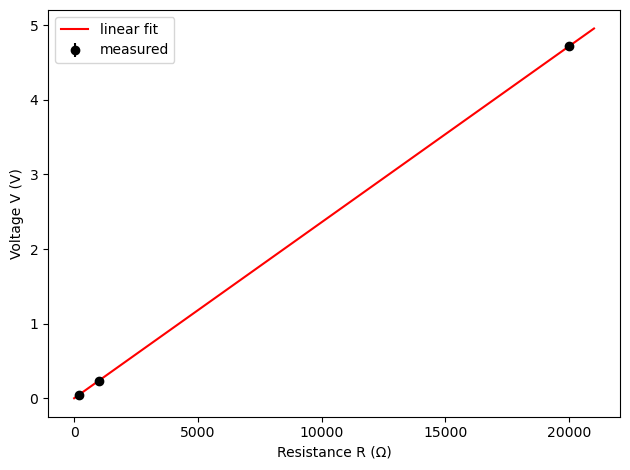

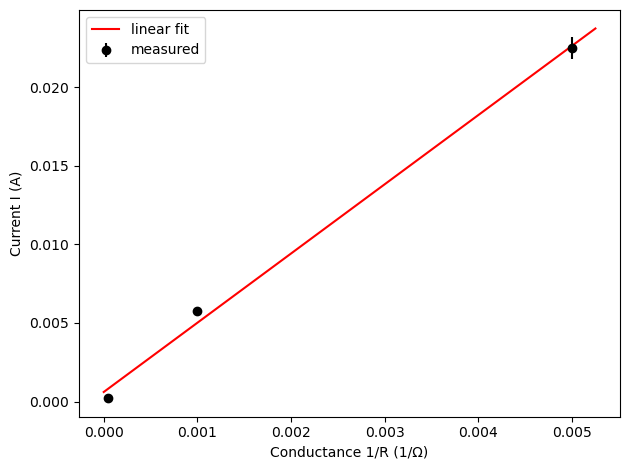

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =======================
# 1. Load and clean data
# =======================

# Set the correct path for your CSV file
FILEPATH = "Task 1.csv"   # change if needed, e.g. "/content/Task 1.csv"

raw = pd.read_csv(FILEPATH)

# Split into series and parallel blocks using the "Series" column
idx_parallel = raw[raw["Series"] == "Parallel"].index[0]
series_raw   = raw.loc[0:idx_parallel-1].reset_index(drop=True)
parallel_raw = raw.loc[idx_parallel+1:].reset_index(drop=True)

def parse_val_with_unit(s, quantity="V"):
    """Convert strings like '47.2 mV' or '0.234 mA' into SI units."""
    import math
    import numpy as np

    if isinstance(s, float) and math.isnan(s):
        return np.nan
    s = str(s).strip()
    if not s:
        return np.nan
    parts = s.split()
    if len(parts) == 1:
        return float(parts[0].replace(",", "."))
    num_str, unit = parts[0], parts[1]
    val = float(num_str.replace(",", "."))
    if quantity == "V":
        factor = {"V": 1.0, "mV": 1e-3}.get(unit, 1.0)
    elif quantity == "A":
        factor = {"A": 1.0, "mA": 1e-3}.get(unit, 1.0)
    else:
        factor = 1.0
    return val * factor

# Create cleaned DataFrames with numeric columns
def clean_block(block):
    out = block.copy()
    out["R_kOhm"] = pd.to_numeric(out["Resistance in kilo ohms"], errors="coerce")
    out["R_Ohm"]  = out["R_kOhm"] * 1e3
    out["V"]      = out["Voltage"].apply(lambda s: parse_val_with_unit(s, "V"))
    out["I"]      = out["Current"].apply(lambda s: parse_val_with_unit(s, "A"))
    return out

series   = clean_block(series_raw)
parallel = clean_block(parallel_raw)

print("Series data (cleaned):")
print(series)
print("\nParallel data (cleaned):")
print(parallel)

# =========================================================
# 2. Type B uncertainties from multimeter datasheet (page 2)
# =========================================================
# DC-Volt 200 mV, 2, 20, 200 V ±(0.5% + 3 Digit)
# DC-Ampere 2, 20 mA ±(0.8% + 3 Digit)
#            200 mA ±(1.2% + 4 Digit)
# Ohm 200 Ω ±(0.8% + 5 Digit)
#     2, 20, 200 kΩ, 2 MΩ ±(0.8% + 3 Digit)
# (Digit sizes below are reasonable assumptions; adjust if you know the exact resolution.)

def volt_uncertainty_dc(V):
    """Return absolute type B uncertainty for a DC voltage reading V [V]."""
    V = float(V)
    absV = abs(V)

    # Choose the next-highest range and corresponding digit size (resolution).
    if absV <= 0.2:
        # 200 mV range, assume 0.1 mV resolution
        digit_size = 0.0001   # 0.1 mV
    elif absV <= 2:
        # 2 V range, assume 1 mV resolution
        digit_size = 0.001    # 1 mV
    elif absV <= 20:
        # 20 V range, assume 10 mV resolution
        digit_size = 0.01     # 10 mV
    else:
        # 200 V range, assume 0.1 V resolution
        digit_size = 0.1

    pct    = 0.005   # 0.5 %
    digits = 3       # "+ 3 Digit"
    return absV * pct + digits * digit_size

def current_uncertainty_dc(I):
    """Return absolute type B uncertainty for a DC current reading I [A]."""
    I = float(I)
    absI = abs(I)

    # Decide between 20 mA and 200 mA range.
    if absI <= 0.02:
        # 20 mA range
        pct        = 0.008      # 0.8 %
        digits     = 3          # "+ 3 Digit"
        digit_size = 0.00001    # 0.01 mA
    else:
        # 200 mA range
        pct        = 0.012      # 1.2 %
        digits     = 4          # "+ 4 Digit"
        digit_size = 0.0001     # 0.1 mA
    return absI * pct + digits * digit_size

def resistance_uncertainty(R):
    """Return absolute type B uncertainty for a resistance reading R [Ω]."""
    R = float(R)
    absR = abs(R)
    # Use Ohm ranges from the manual
    if absR <= 200:
        # 200 Ω range, assume 0.1 Ω resolution
        pct        = 0.008      # 0.8 %
        digits     = 5
        digit_size = 0.1
    elif absR <= 2e5:
        # 2 kΩ ... 200 kΩ range, assume 1 Ω resolution
        pct        = 0.008
        digits     = 3
        digit_size = 1.0
    else:
        # 20 MΩ range etc. (not relevant here)
        pct        = 0.01
        digits     = 15
        digit_size = 10.0
    return absR * pct + digits * digit_size

# Apply uncertainties
series["uV"] = series["V"].apply(lambda x: np.nan if np.isnan(x) else volt_uncertainty_dc(x))
series["uI"] = series["I"].apply(lambda x: np.nan if np.isnan(x) else current_uncertainty_dc(x))
series["uR"] = series["R_Ohm"].apply(lambda x: resistance_uncertainty(x))

parallel["uV"] = parallel["V"].apply(lambda x: np.nan if np.isnan(x) else volt_uncertainty_dc(x))
parallel["uI"] = parallel["I"].apply(lambda x: current_uncertainty_dc(x))
parallel["uR"] = parallel["R_Ohm"].apply(lambda x: resistance_uncertainty(x))

print("\nSeries data with uncertainties:")
print(series[["R_Ohm", "V", "uV", "I", "uI", "uR"]])

print("\nParallel data with uncertainties:")
print(parallel[["R_Ohm", "V", "uV", "I", "uI", "uR"]])

# ==============================
# 3. Theoretical values (U = 5V)
# ==============================

U_supply = 5.0    # V

# --- Series circuit ---
R_total_series = series["R_Ohm"].sum()
I_theo_series  = U_supply / R_total_series         # same for all series resistors
series["I_theo"] = I_theo_series
series["V_theo"] = I_theo_series * series["R_Ohm"]

# --- Parallel circuit ---
parallel["V_theo"] = U_supply                      # same across each branch
parallel["I_theo"] = U_supply / parallel["R_Ohm"]

print("\nTheoretical values for series circuit:")
print(series[["R_Ohm", "V_theo", "I_theo"]])

print("\nTheoretical values for parallel circuit:")
print(parallel[["R_Ohm", "V_theo", "I_theo"]])

# ==========================================
# 4. Linear fits and plots required for Task 1
# ==========================================

# 4.1 Series: V vs R (expect V = I * R)
series_nonan = series.dropna(subset=["V", "R_Ohm"])
x_series = series_nonan["R_Ohm"].values
y_series = series_nonan["V"].values
yerr_series = series_nonan["uV"].values

# Linear fit: y = a * x + b
coeffs_series, cov_series = np.polyfit(x_series, y_series, 1, cov=True)
a_series, b_series = coeffs_series
sa_series = np.sqrt(cov_series[0, 0])
sb_series = np.sqrt(cov_series[1, 1])

plt.figure()
plt.errorbar(
    x_series, y_series, yerr=yerr_series, 
    fmt="o", color="black", ecolor="black", label="measured"
)
R_fit = np.linspace(0, x_series.max()*1.05, 100)
V_fit = a_series * R_fit + b_series
plt.plot(R_fit, V_fit, color="red", label="linear fit")
plt.xlabel("Resistance R (Ω)")
plt.ylabel("Voltage V (V)")
plt.legend()
plt.tight_layout()
plt.savefig("task1_series_V_vs_R.png", dpi=300)
plt.show()


# 4.2 Parallel: I vs 1/R (expect I = U * (1/R))
parallel_nonan = parallel.dropna(subset=["I", "R_Ohm"])
x_par = 1.0 / parallel_nonan["R_Ohm"].values
y_par = parallel_nonan["I"].values
yerr_par = parallel_nonan["uI"].values

coeffs_par, cov_par = np.polyfit(x_par, y_par, 1, cov=True)
a_par, b_par = coeffs_par
sa_par = np.sqrt(cov_par[0, 0])
sb_par = np.sqrt(cov_par[1, 1])

plt.figure()
plt.errorbar(
    x_par, y_par, yerr=yerr_par, 
    fmt="o", color="black", ecolor="black", label="measured"
)
x_fit = np.linspace(0, x_par.max()*1.05, 100)
I_fit = a_par * x_fit + b_par
plt.plot(x_fit, I_fit, color="red", label="linear fit")
plt.xlabel("Conductance 1/R (1/Ω)")
plt.ylabel("Current I (A)")
plt.legend()
plt.tight_layout()
plt.savefig("task1_parallel_I_vs_invR.png", dpi=300)
plt.show()

Raw Task 2 data:
    RL in ohm  Voltage in V      RL    UL
0         170          2.08     170  2.08
1         180          2.15     180  2.15
2         200          2.25     200  2.25
3         250          2.48     250  2.48
4         300          2.66     300  2.66
5         400          2.92     400  2.92
6         600          3.24     600  3.24
7        1000          3.55    1000  3.55
8        3000          3.93    3000  3.93
9        8000          4.07    8000  4.07
10      20000          4.12   20000  4.12
11      60000          4.15   60000  4.15
12     100000          4.15  100000  4.15

Task 2 with theoretical UL:
    RL in ohm  Voltage in V      RL    UL     u_UL   UL_theo
0         170          2.08     170  2.08  0.04040  2.103960
1         180          2.15     180  2.15  0.04075  2.163462
2         200          2.25     200  2.25  0.04125  2.272727
3         250          2.48     250  2.48  0.04240  2.500000
4         300          2.66     300  2.66  0.04330  2.678571


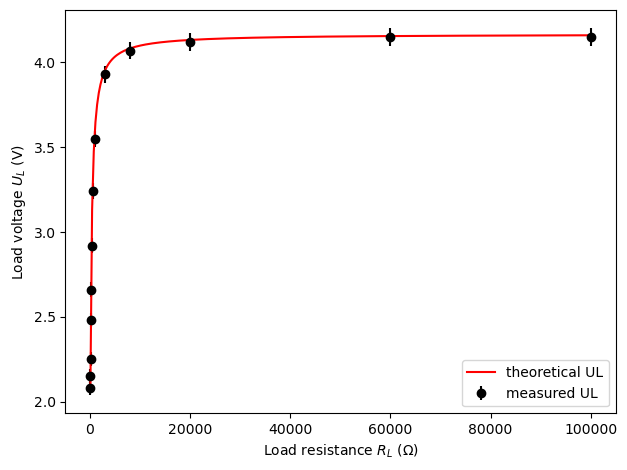


Fit results for U/UL vs 1/RL:
a = 203.736 ± 0.341  (expected R1 = 200 Ω)
b = 1.203 ± 0.001  (expected 1 + R1/R2 = 1.2)


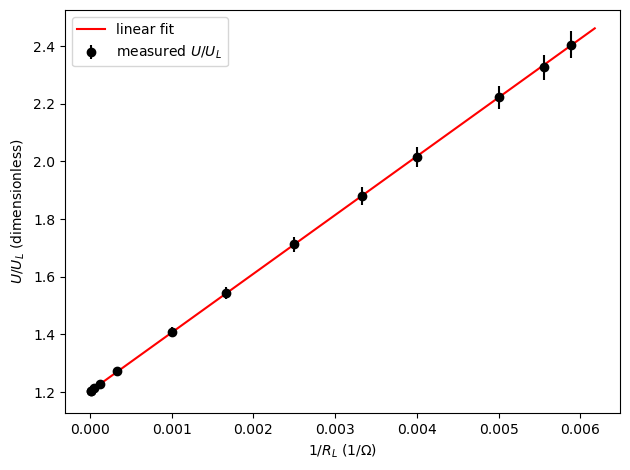

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# 1. Load Task 2 CSV
# ============================

FILEPATH = "Task 2.csv"   # change if needed
df = pd.read_csv(FILEPATH)

# Expect column names like "RL in ohm" and "Voltage in V"
df = df.rename(columns=lambda c: c.strip())

df["RL"] = pd.to_numeric(df["RL in ohm"], errors="coerce")   # Ω
df["UL"] = pd.to_numeric(df["Voltage in V"], errors="coerce")  # V

print("Raw Task 2 data:")
print(df)

# ============================
# 2. Constants & helpers
# ============================

U_supply = 5.0      # V
R1 = 0.2e3          # 0.2 kΩ in Ω
R2 = 1.0e3          # 1 kΩ in Ω

def volt_uncertainty_dc(V):
    """
    Type B uncertainty for DC voltage (from manual):
    200 mV, 2, 20, 200 V  ±(0.5% + 3 Digit)
    Digit sizes assumed as in Task 1.
    """
    V = float(V)
    absV = abs(V)

    if absV <= 0.2:
        digit_size = 0.0001  # 0.1 mV
    elif absV <= 2:
        digit_size = 0.001   # 1 mV
    elif absV <= 20:
        digit_size = 0.01    # 10 mV
    else:
        digit_size = 0.1     # 0.1 V (200 V range)

    pct    = 0.005  # 0.5%
    digits = 3
    return absV * pct + digits * digit_size

# Uncertainty of measured load voltage UL
df["u_UL"] = df["UL"].apply(volt_uncertainty_dc)

# ============================
# 3. Theoretical UL(RL)
# ============================

def UL_theoretical(RL, R1, R2, U):
    # R2 in parallel with RL
    R2_par = (R2 * RL) / (R2 + RL)
    return U * R2_par / (R1 + R2_par)

df["UL_theo"] = UL_theoretical(df["RL"].values, R1, R2, U_supply)

print("\nTask 2 with theoretical UL:")
print(df)

# ============================
# 4. Linearised quantities
#    U / UL vs 1/RL
# ============================

df["inv_RL"] = 1.0 / df["RL"]          # 1/Ω
df["U_over_UL"] = U_supply / df["UL"]  # dimensionless

# Propagate UL uncertainty into U/UL:
# f = U / UL  ->  df/dUL = -U / UL^2
df["u_U_over_UL"] = (U_supply / (df["UL"]**2)) * df["u_UL"]

print("\nLinearised data:")
print(df[["RL", "UL", "u_UL", "inv_RL", "U_over_UL", "u_U_over_UL"]])

# ============================
# 5. Graph 1: UL vs RL
# ============================

RL_vals = df["RL"].values
UL_vals = df["UL"].values
u_UL_vals = df["u_UL"].values
UL_theo_vals = df["UL_theo"].values

plt.figure()
plt.errorbar(
    RL_vals, UL_vals, yerr=u_UL_vals,
    fmt="o", color="black", ecolor="black",
    label="measured UL"
)
# smooth theoretical curve for same RL range
RL_smooth = np.linspace(RL_vals.min(), RL_vals.max(), 300)
UL_smooth = UL_theoretical(RL_smooth, R1, R2, U_supply)
plt.plot(RL_smooth, UL_smooth, color="red", label="theoretical UL")

plt.xlabel(r"Load resistance $R_L$ (Ω)")
plt.ylabel(r"Load voltage $U_L$ (V)")
plt.legend()
plt.tight_layout()
plt.savefig("task2_UL_vs_RL.png", dpi=300)
plt.show()

# ============================
# 6. Graph 2: U/UL vs 1/RL (linear fit)
# ============================

mask = np.isfinite(df["inv_RL"]) & np.isfinite(df["U_over_UL"])
x = df.loc[mask, "inv_RL"].values
y = df.loc[mask, "U_over_UL"].values
yerr = df.loc[mask, "u_U_over_UL"].values

# Weighted linear fit: y = a*x + b
w = 1.0 / (yerr**2)
# polyfit does not support weights directly for covariance in all versions,
# but we can use np.polyfit with 'w' to get best-fit parameters, then estimate covariance.
coeffs = np.polyfit(x, y, 1, w=w)
a_fit, b_fit = coeffs

# Estimate covariance approximately
y_fit = a_fit * x + b_fit
residuals = y - y_fit
dof = len(x) - 2
sigma2 = np.sum(w * residuals**2) / dof
Sxx = np.sum(w * (x - np.average(x, weights=w))**2)
sa = np.sqrt(sigma2 / Sxx)
sb = np.sqrt(sigma2 * (1.0 / np.sum(w) + (np.average(x, weights=w)**2) / Sxx))

print("\nFit results for U/UL vs 1/RL:")
print(f"a = {a_fit:.3f} ± {sa:.3f}  (expected R1 = 200 Ω)")
print(f"b = {b_fit:.3f} ± {sb:.3f}  (expected 1 + R1/R2 = 1.2)")

plt.figure()
plt.errorbar(
    x, y, yerr=yerr,
    fmt="o", color="black", ecolor="black",
    label=r"measured $U/U_L$"
)
x_fit = np.linspace(0, x.max()*1.05, 300)
y_fit_line = a_fit * x_fit + b_fit
plt.plot(x_fit, y_fit_line, color="red", label="linear fit")

plt.xlabel(r"$1/R_L$ (1/Ω)")
plt.ylabel(r"$U/U_L$ (dimensionless)")
plt.legend()
plt.tight_layout()
plt.savefig("task2_UoverUL_vs_invRL.png", dpi=300)
plt.show()

Raw Task 3 data:
    R4 in ohm       UB Unnamed: 2
0         100   2.41 V        NaN
1         300   1.14 V        NaN
2         500  0.588 V        NaN
3         600  0.413 V        NaN
4         700  0.276 V        NaN
5         750  0.218 V        NaN
6         800  0.167 V        NaN
7         830  0.138 V        NaN
8         860   0.11 V        NaN
9         880  93.1 mV        NaN
10        900  76.5 mV        NaN
11        920  60.2 mV        NaN
12        940  44.6 mV        NaN
13        960  29.9 mV        NaN
14        980  15.4 mV        NaN
15        990   7.4 mV        NaN
16        995   3.9 mV        NaN
17       1000   2.1 mV        NaN
18       1002   1.3 mV        NaN
19       1003  0.7 mV         NaN
20       1004        0        NaN
21       1005     -0.7         mV
22       1010     -4.1         mV
23       1020    -10.6         mV
24       1050    -29.7         mV
25       1500    -0.24          V
26       3000   -0.515          V
27       5000   -0.636         

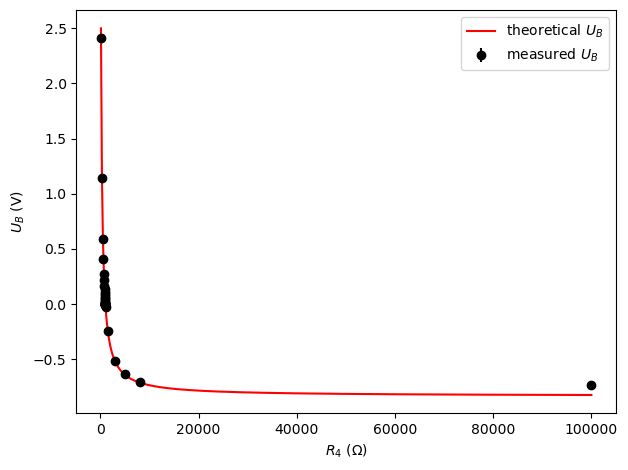


Fit result for R2:
R2_fit = 1002.897 ± 0.132 Ω (nominal R2 = 1000.000 Ω)


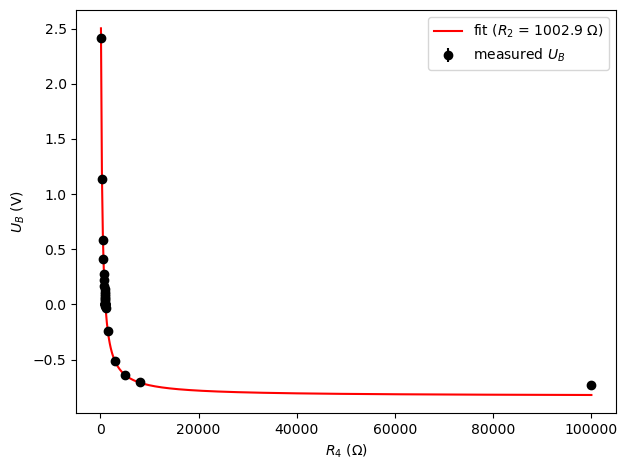

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====================================
# 1. Load raw Task 3 data
# ====================================

FILEPATH = "Task 3.csv"   # adjust if needed
raw = pd.read_csv(FILEPATH)
raw = raw.rename(columns=lambda c: c.strip())

print("Raw Task 3 data:")
print(raw)

# Expect columns like: 'R4 in ohm', 'UB', 'Unnamed: 2'
# Combine the UB + possible unit column into one string
if raw.shape[1] >= 3:
    UB_str = raw.iloc[:, 1].astype(str) + " " + raw.iloc[:, 2].fillna("").astype(str)
else:
    UB_str = raw.iloc[:, 1].astype(str)


# ====================================
# 2. Robust voltage parser
# ====================================
def parse_voltage_to_V(s):
    """
    Convert strings like:
    '2.41 V', '93.1 mV', '-4.1 mV', '-0.7mV', '0', etc. to volts.
    """
    s = str(s).strip().replace(",", ".")
    if s == "" or s.lower() == "nan":
        return np.nan

    s_lower = s.lower()

    # millivolts
    if "mv" in s_lower:
        num_str = s_lower.replace("mv", "")
        return float(num_str) * 1e-3

    # volts with explicit 'v'
    if "v" in s_lower:
        num_str = s_lower.replace("v", "")
        return float(num_str)

    # plain number -> assume volts
    return float(s)


df = pd.DataFrame()
df["R4"] = pd.to_numeric(raw.iloc[:, 0], errors="coerce")     # Ω
df["UB"] = UB_str.apply(parse_voltage_to_V)                   # V

print("\nCleaned Task 3 data (R4, UB in V):")
print(df)

# ====================================
# 3. Constants and uncertainty helpers
# ====================================

U_supply = 5.0       # V
R1 = 200.0           # Ω
R3 = 200.0           # Ω
R2_nominal = 1000.0  # Ω (nominal, to compare with fit)

# DC-Volt type B uncertainty (manual page 2)
def volt_uncertainty_dc(V):
    """
    200 mV, 2, 20, 200 V ranges:
    ±(0.5% of reading + 3 digits)
    digit sizes chosen as in Tasks 1 & 2.
    """
    V = float(V)
    absV = abs(V)

    if absV <= 0.2:
        digit_size = 0.0001   # 0.1 mV
    elif absV <= 2:
        digit_size = 0.001    # 1 mV
    elif absV <= 20:
        digit_size = 0.01     # 10 mV
    else:
        digit_size = 0.1      # 0.1 V

    pct    = 0.005  # 0.5 %
    digits = 3
    return absV * pct + digits * digit_size

# Ohm type B uncertainty (manual page 2)
def resistance_uncertainty(R):
    """
    200 Ω range: ±(0.8% + 5 digits)
    2, 20, 200 kΩ, 2 MΩ ranges: ±(0.8% + 3 digits)
    """
    R = float(R)
    absR = abs(R)

    if absR <= 200:
        pct        = 0.008
        digits     = 5
        digit_size = 0.1
    elif absR <= 2e5:
        pct        = 0.008
        digits     = 3
        digit_size = 1.0
    else:
        pct        = 0.01
        digits     = 15
        digit_size = 10.0

    return absR * pct + digits * digit_size

df["u_R4"] = df["R4"].apply(resistance_uncertainty)
df["u_UB"] = df["UB"].apply(volt_uncertainty_dc)

print("\nData with uncertainties:")
print(df)

# ====================================
# 4. Theoretical bridge voltage UB(R4)
# ====================================
def UB_theoretical(R4, R1, R2, R3, U):
    """
    Wheatstone bridge:
    U_B = U_left_mid - U_right_mid
    where:
      U_left_mid  = U * R2 / (R1 + R2)
      U_right_mid = U * R4 / (R3 + R4)
    """
    V_left  = U * R2 / (R1 + R2)
    V_right = U * R4 / (R3 + R4)
    return V_left - V_right

df["UB_theo"] = UB_theoretical(df["R4"], R1, R2_nominal, R3, U_supply)

print("\nSample of theoretical UB:")
print(df[["R4", "UB", "UB_theo"]].head())

# ====================================
# 5. Plot 1 — UB vs R4 (measured vs theory)
# ====================================

R4_vals = df["R4"].values
UB_vals = df["UB"].values
uUB_vals = df["u_UB"].values

plt.figure()
plt.errorbar(
    R4_vals, UB_vals, yerr=uUB_vals,
    fmt="o", color="black", ecolor="black",
    label="measured $U_B$"
)
R4_smooth = np.linspace(R4_vals.min(), R4_vals.max(), 500)
UB_smooth = UB_theoretical(R4_smooth, R1, R2_nominal, R3, U_supply)
plt.plot(R4_smooth, UB_smooth, color="red", label="theoretical $U_B$")

plt.xlabel(r"$R_4$ (Ω)")
plt.ylabel(r"$U_B$ (V)")
plt.legend()
plt.tight_layout()
plt.savefig("task3_UB_vs_R4.png", dpi=300)
plt.show()

# ====================================
# 6. Nonlinear fit to determine R2
# ====================================

try:
    from scipy.optimize import curve_fit
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

def model_UB(R4, R2):
    return UB_theoretical(R4, R1, R2, R3, U_supply)

mask = np.isfinite(R4_vals) & np.isfinite(UB_vals)
x_fit = R4_vals[mask]
y_fit = UB_vals[mask]
sigma_y = uUB_vals[mask]

if SCIPY_OK:
    popt, pcov = curve_fit(
        model_UB,
        x_fit, y_fit,
        p0=[R2_nominal],
        sigma=sigma_y,
        absolute_sigma=True,
        maxfev=10000
    )
    R2_fit = popt[0]
    s_R2 = np.sqrt(np.diag(pcov))[0]
else:
    # Simple gradient-descent fallback (SciPy almost always available)
    R2_fit = R2_nominal
    for _ in range(3000):
        UB_pred = model_UB(x_fit, R2_fit)
        res = (y_fit - UB_pred) / sigma_y**2
        dR = 1.0
        UB_pred_d = model_UB(x_fit, R2_fit + dR)
        dUB_dR = (UB_pred_d - UB_pred) / dR
        grad = -2 * np.sum(res * dUB_dR)
        R2_fit -= 1e-6 * grad
    s_R2 = np.nan  # rough estimate not available here

print(f"\nFit result for R2:")
print(f"R2_fit = {R2_fit:.3f} ± {s_R2:.3f} Ω (nominal R2 = {R2_nominal:.3f} Ω)")

# ====================================
# 7. Plot 2 — UB vs R4 with fitted curve
# ====================================

UB_fit_curve = model_UB(R4_smooth, R2_fit)

plt.figure()
plt.errorbar(
    R4_vals, UB_vals, yerr=uUB_vals,
    fmt="o", color="black", ecolor="black",
    label="measured $U_B$"
)
plt.plot(R4_smooth, UB_fit_curve, color="red", label=f"fit ($R_2$ = {R2_fit:.1f} Ω)")

plt.xlabel(r"$R_4$ (Ω)")
plt.ylabel(r"$U_B$ (V)")
plt.legend()
plt.tight_layout()
plt.savefig("task3_UB_vs_R4_fit.png", dpi=300)
plt.show()

Raw Task 4 data:
    Frequency (Hz) A (outcoming) (mV) B (incoming) (V)
0            100.0              61.24             1598
1            300.0              79.96             1598
2            500.0              70.54             1598
3            700.0              61.92             1598
4            900.0              70.36             1598
5           1000.0              70.44             1598
6           3000.0              132.3             1598
7           5000.0              194.8             1580
8           7000.0              255.9             1563
9           9000.0              308.8             1554
10         10000.0              344.1             1536
11         30000.0              705.9             1324
12         50000.0              847.1             1174
13         70000.0              882.4             1095
14         90000.0              902.2             1024
15        100000.0                900             1007
16             NaN                NaN           

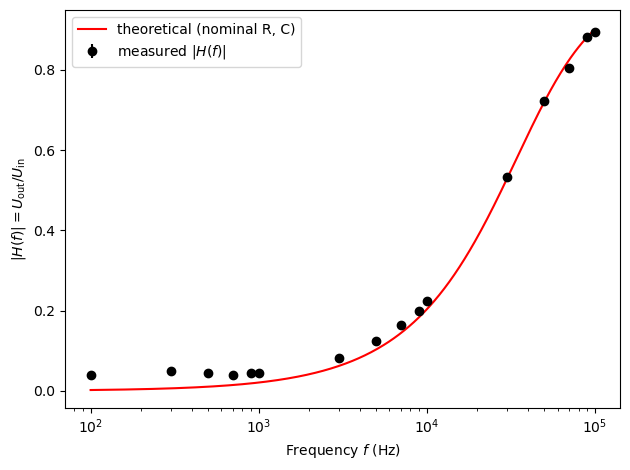


Fit result for cutoff frequency:
fc_fit = 33844.97 ± 143.16 Hz (nominal fc = 48228.77 Hz)
Corresponding RC_fit = 4.702e-06 s, nominal RC = 3.300e-06 s


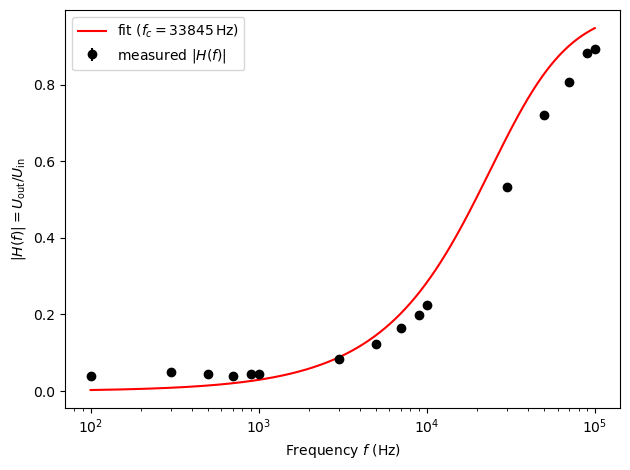

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 1. Load and clean Task 4 data
# ==============================

FILEPATH = "Task 4.csv"  # adjust if needed
raw = pd.read_csv(FILEPATH)
raw = raw.rename(columns=lambda c: c.strip())

print("Raw Task 4 data:")
print(raw)

# Expect columns: Frequency (Hz), A (outcoming) (mV), B (incoming) (V) [actually mV]
df = pd.DataFrame()
df["f_Hz"]  = pd.to_numeric(raw.iloc[:, 0], errors="coerce")
df["A_mV"]  = pd.to_numeric(raw.iloc[:, 1], errors="coerce")  # output
df["B_mV"]  = pd.to_numeric(raw.iloc[:, 2], errors="coerce")  # input (also mV)

# Drop any footer rows (like "Capacitor 3.3 nF")
df = df.dropna(subset=["f_Hz", "A_mV", "B_mV"]).reset_index(drop=True)

# Convert to volts
df["U_out"] = df["A_mV"] * 1e-3  # V
df["U_in"]  = df["B_mV"] * 1e-3  # V

print("\nCleaned Task 4 data (in volts):")
print(df)

# ==============================
# 2. Constants & uncertainty models
# ==============================

R = 1.0e3          # 1 kΩ
C = 3.3e-9         # 3.3 nF
U_supply = 5.0     # supply (not directly needed but good to note)

# Nominal cutoff frequency
fc_nom = 1.0 / (2.0 * np.pi * R * C)
print(f"\nNominal cutoff frequency fc_nom = {fc_nom:.2f} Hz")

def volt_uncertainty_dc(V):
    """
    Type B uncertainty for voltage (from manual, like in previous tasks):
    200 mV, 2, 20, 200 V ranges: ±(0.5% of reading + 3 digits)
    We approximate digit sizes as in Tasks 1–3.
    """
    V = float(V)
    absV = abs(V)

    if absV <= 0.2:
        digit_size = 0.0001   # 0.1 mV
    elif absV <= 2:
        digit_size = 0.001    # 1 mV
    elif absV <= 20:
        digit_size = 0.01     # 10 mV
    else:
        digit_size = 0.1      # 0.1 V

    pct    = 0.005  # 0.5%
    digits = 3
    return absV * pct + digits * digit_size

# Uncertainties for input and output amplitudes
df["u_U_out"] = df["U_out"].apply(volt_uncertainty_dc)
df["u_U_in"]  = df["U_in"].apply(volt_uncertainty_dc)

print("\nData with amplitude uncertainties:")
print(df[["f_Hz", "U_out", "u_U_out", "U_in", "u_U_in"]])

# ==============================
# 3. Transfer function magnitude |H(f)|
# ==============================

df["H_abs"] = df["U_out"] / df["U_in"]

# Propagate uncertainty: H = A/B
# ∂H/∂A = 1/B, ∂H/∂B = -A/B^2
df["u_H_abs"] = np.sqrt(
    (df["u_U_out"] / df["U_in"])**2 +
    ((df["U_out"] * df["u_U_in"]) / (df["U_in"]**2))**2
)

print("\nTransfer function |H(f)| with uncertainties:")
print(df[["f_Hz", "H_abs", "u_H_abs"]])

# ==============================
# 4. Theoretical high-pass transfer function
# ==============================

def H_highpass(f, R, C):
    """Magnitude of RC high-pass filter transfer function."""
    omega = 2.0 * np.pi * f
    omegaRC = omega * R * C
    return omegaRC / np.sqrt(1.0 + omegaRC**2)

df["H_theo_nom"] = H_highpass(df["f_Hz"].values, R, C)

# ==============================
# 5. Plot 1: measured vs theoretical |H(f)|
# ==============================

f_vals = df["f_Hz"].values
H_vals = df["H_abs"].values
uH_vals = df["u_H_abs"].values
H_theo_vals = df["H_theo_nom"].values

plt.figure()
plt.errorbar(
    f_vals, H_vals, yerr=uH_vals,
    fmt="o", color="black", ecolor="black",
    label=r"measured $|H(f)|$"
)

f_smooth = np.logspace(np.log10(f_vals.min()), np.log10(f_vals.max()), 400)
H_smooth = H_highpass(f_smooth, R, C)
plt.plot(f_smooth, H_smooth, color="red", label="theoretical (nominal R, C)")

plt.xscale("log")
plt.xlabel(r"Frequency $f$ (Hz)")
plt.ylabel(r"$|H(f)| = U_{\mathrm{out}}/U_{\mathrm{in}}$")
plt.legend()
plt.tight_layout()
plt.savefig("task4_transfer_HP_meas_vs_theory.png", dpi=300)
plt.show()

# ==============================
# 6. Nonlinear fit to determine cutoff frequency fc
# ==============================

try:
    from scipy.optimize import curve_fit
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

def H_model_fc(f, fc):
    """
    High-pass transfer in terms of cutoff frequency fc:
    |H| = (f/fc) / sqrt(1 + (f/fc)^2)
    """
    x = f / fc
    return x / np.sqrt(1.0 + x**2)

mask = np.isfinite(f_vals) & np.isfinite(H_vals) & np.isfinite(uH_vals)
f_fit = f_vals[mask]
H_fit = H_vals[mask]
sigma_H = uH_vals[mask]

if SCIPY_OK:
    popt, pcov = curve_fit(
        H_model_fc,
        f_fit, H_fit,
        p0=[fc_nom],
        sigma=sigma_H,
        absolute_sigma=True,
        maxfev=10000
    )
    fc_fit = popt[0]
    s_fc = np.sqrt(np.diag(pcov))[0]
else:
    # crude fallback if SciPy isn't available
    fc_fit = fc_nom
    for _ in range(3000):
        H_pred = H_model_fc(f_fit, fc_fit)
        res = (H_fit - H_pred) / sigma_H**2
        d_fc = 1.0
        H_pred_d = H_model_fc(f_fit, fc_fit + d_fc)
        dH_dfc = (H_pred_d - H_pred) / d_fc
        grad = -2.0 * np.sum(res * dH_dfc)
        fc_fit -= 1e-6 * grad
    s_fc = np.nan

RC_fit = 1.0 / (2.0 * np.pi * fc_fit)

print(f"\nFit result for cutoff frequency:")
print(f"fc_fit = {fc_fit:.2f} ± {s_fc:.2f} Hz (nominal fc = {fc_nom:.2f} Hz)")
print(f"Corresponding RC_fit = {RC_fit:.3e} s, nominal RC = {R*C:.3e} s")

# ==============================
# 7. Plot 2: evaluation plot with fitted curve
# ==============================

H_fit_curve = H_model_fc(f_smooth, fc_fit)

plt.figure()
plt.errorbar(
    f_vals, H_vals, yerr=uH_vals,
    fmt="o", color="black", ecolor="black",
    label=r"measured $|H(f)|$"
)
plt.plot(f_smooth, H_fit_curve, color="red",
         label=fr"fit ($f_c = {fc_fit:.0f}\,\mathrm{{Hz}}$)")

plt.xscale("log")
plt.xlabel(r"Frequency $f$ (Hz)")
plt.ylabel(r"$|H(f)| = U_{\mathrm{out}}/U_{\mathrm{in}}$")
plt.legend()
plt.tight_layout()
plt.savefig("task4_transfer_HP_fit.png", dpi=300)
plt.show()